In [1]:
import pandas as pd
import lib.preprocessing as pre
import importlib
import config.settings as settings

root_path = settings.ROOT_DIR

importlib.reload(pre)
# goods_df = pd.read_csv('data/marked.csv')
goods_df = pd.read_excel(root_path / 'data/marked.xlsx', sheet_name='Data_new')
names_list = pre.preprocess_names_list(goods_df['name'].tolist())
goods_df['name'] = names_list
df = goods_df[['name', 'target']].where(goods_df['target'] != -1).dropna()
df['target'] = goods_df['target'].astype(int)
df

[nltk_data] Downloading package stopwords to C:\Users\Admin\Documents\
[nltk_data]     Study\Projects\7_semester\MDP\lib\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 7687/7687 [00:00<00:00, 99822.02it/s]


,name,target
0,салатный микс модена,3
1,салат кейл,3
2,лонган,1
3,шпинат,3
4,салатный микс аликанте,3
...,...,...
7682,мини-круассаны сливочным кремом яшкино,23
7683,мини-круассаны яшкино клубничным джемом,23
7684,хлебные палочки grissini томатом baker house,23
7685,соломка солёная чудесный край,23


In [2]:
print(sorted(df['target'].unique().tolist()))
print(df['target'].dtype)
print(df['target'].isna().sum())
print(len(df['target'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
int64
0
25


In [3]:
import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    EarlyStoppingCallback
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используется устройство:", device)

Используется устройство: cuda


In [4]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [5]:
dataset = Dataset.from_pandas(df)

models_path = root_path / 'ml/models'
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2", cache_dir=models_path)

def tokenize(batch):
    return tokenizer(batch["name"], truncation=True, padding='max_length', max_length=32)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("target", "labels")
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_test = dataset.train_test_split(test_size=0.2)

model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2",
    num_labels=df['target'].max() + 1,
    cache_dir=models_path
).to(device)

Map:   0%|          | 0/7665 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,  # Ждать 5 эпох без улучшения eval_loss
    early_stopping_threshold=0.0
)

training_args = TrainingArguments(
    output_dir= models_path / "bert-finetuned",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    num_train_epochs=100,
    eval_strategy="epoch",
    logging_strategy='epoch',
    save_total_limit=2,
    fp16=True,
    metric_for_best_model="eval_loss",
    weight_decay=0.01
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

print("Начало тренировки...")
trainer.train()

print("\n--- Финальная оценка лучшей модели (на валидационном наборе) ---")
final_eval = trainer.evaluate()
print(final_eval)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11340\3487048441.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Начало тренировки...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.980300,2.710579,0.405088,0.263831,0.405088,0.289280
2,2.475200,2.153659,0.551207,0.466198,0.551207,0.459453
3,2.005600,1.741898,0.666014,0.615270,0.666014,0.608256
4,1.647900,1.428841,0.742335,0.665644,0.742335,0.690695
5,1.364900,1.194254,0.776256,0.722087,0.776256,0.731559
6,1.145100,1.021129,0.795173,0.747327,0.795173,0.755362
7,0.974800,0.886008,0.810828,0.765779,0.810828,0.777267
8,0.841800,0.785177,0.822570,0.784448,0.822570,0.791762
9,0.740300,0.706468,0.833007,0.808718,0.833007,0.806061
10,0.655300,0.641347,0.847358,0.863422,0.847358,0.824939



--- Финальная оценка лучшей модели (на валидационном наборе) ---


{'eval_loss': 0.28460076451301575, 'eval_accuracy': 0.9308545335942596, 'eval_precision': 0.9315434087052396, 'eval_recall': 0.9308545335942596, 'eval_f1': 0.9302443574472461, 'eval_runtime': 1.8008, 'eval_samples_per_second': 851.277, 'eval_steps_per_second': 106.618, 'epoch': 40.0}


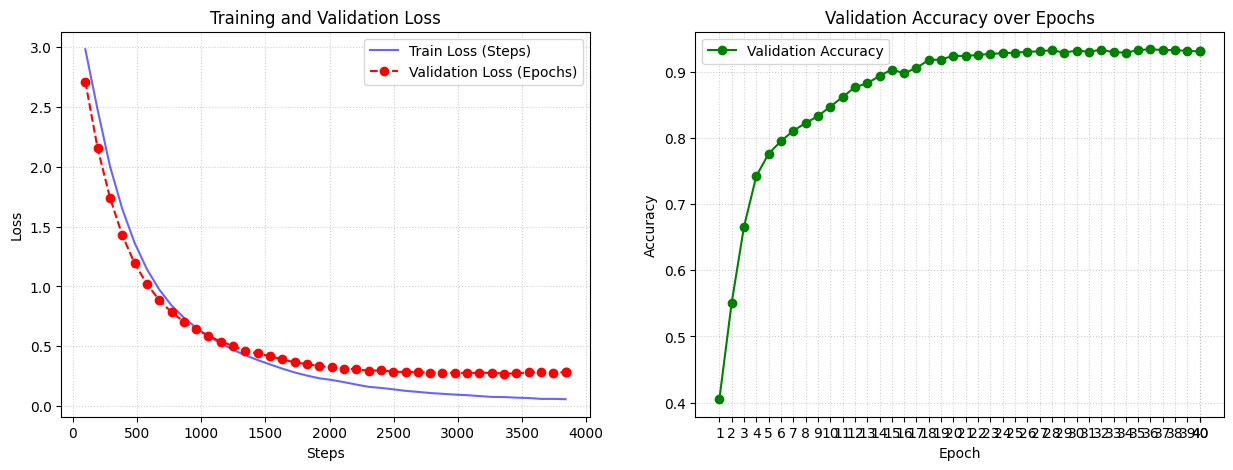

In [7]:
import lib.ml_metrics as ml_metrics
importlib.reload(ml_metrics)

metrics = ml_metrics.extract_metrics(trainer.state.log_history)
ml_metrics.plot_metrics(metrics)

In [8]:
# from sklearn.preprocessing import LabelEncoder
# import joblib
#
# cat_df  = pd.read_excel(root_path / 'data/full_marked.xlsx', sheet_name='Category')
# # Берём список всех категорий (номеров)
# category_ids = cat_df["Номер категории"].tolist()
#
# # Создаём LabelEncoder и обучаем на НОМЕРАХ категорий
# le = LabelEncoder()
# le.fit(category_ids)
#
# # Сохраняем
# joblib.dump(le, models_path / "label_encoder.pkl")
#
# # Применяем к твоим данным
# df["target_enc"] = le.transform(df["target"])
#
# print("Классы LabelEncoder:", le.classes_)
# print("Количество классов:", len(le.classes_))
# df["target"] = df["target_enc"]

In [9]:
print("\n--- Финальная оценка на тестовом множестве ---")
final_metrics = trainer.evaluate(eval_dataset=train_test["test"])

print(f"Accuracy: {final_metrics['eval_accuracy']:.4f}")
print(f"Precision: {final_metrics['eval_precision']:.4f}")
print(f"Recall: {final_metrics['eval_recall']:.4f}")
print(f"F1: {final_metrics['eval_f1']:.4f}")


--- Финальная оценка на тестовом множестве ---
Accuracy: 0.9309
Precision: 0.9315
Recall: 0.9309
F1: 0.9302


In [10]:
import os
import torch
import torch.onnx
from pathlib import Path

onnx_export_dir = models_path.parent / 'results'
os.makedirs(onnx_export_dir, exist_ok=True)
onnx_path = onnx_export_dir / "rubert_tiny2_seq_class.onnx"

print(f"\n--- Экспорт модели в ONNX: {onnx_path} ---")

# 1. Загрузка лучшей модели (она уже загружена в `trainer.model` благодаря load_best_model_at_end=True)
model_to_export = trainer.model.to('cpu').eval()
tokenizer_to_export = trainer.tokenizer

# 2. Создание фиктивного входного тензора
# Используем размерность, соответствующую вашим данным (max_length=32)
max_seq_length = 32

dummy_input_ids = torch.randint(0, tokenizer_to_export.vocab_size, (1, max_seq_length))
dummy_attention_mask = torch.ones(1, max_seq_length, dtype=torch.long)

# Входные данные для трассировки должны быть в виде кортежа, как ожидает модель
dummy_input = (dummy_input_ids, dummy_attention_mask)

# 3. Экспорт
torch.onnx.export(
    model_to_export,
    dummy_input,
    onnx_path,
    export_params=True,

    opset_version=17,

    do_constant_folding=True,
    input_names=['input_ids', 'attention_mask'],
    output_names=['logits'],
    dynamic_axes={
        'input_ids': {0: 'batch_size'},
        'attention_mask': {0: 'batch_size'},
        'logits': {0: 'batch_size'}
    }
)

print(f"Модель успешно сохранена в ONNX по пути: {onnx_path}")

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.



--- Экспорт модели в ONNX: C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\ml\results\rubert_tiny2_seq_class.onnx ---


C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\mdp_venv\Lib\site-packages\transformers\modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


Модель успешно сохранена в ONNX по пути: C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\ml\results\rubert_tiny2_seq_class.onnx
